# Final Projections

This notebook will house our final WTI Spot projections with Bear, Base and Pull cases using terciles of monte carlo simulation pathways

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from arch import arch_model
from scipy.stats import t

In [2]:
df_ens = pd.read_pickle('Final_Regression_Set.pkl')

In [3]:
df_ens

,Chng_WTI_Spot,Spot-Cl1_lag1,BZ1_CL1_change_lag4,Chng_CushingStocks_lag1,WTI_Spot
2015-03-06,1.22,-0.370000,1.640000,536.0,50.38
2015-03-13,-2.69,-0.022000,0.042000,2322.0,47.69
2015-03-20,-3.30,0.020000,3.448000,2865.0,44.39
2015-03-27,4.29,0.054000,1.754001,1911.0,48.68
2015-04-03,0.23,-0.213999,-0.972001,2629.0,48.91
...,...,...,...,...,...
2026-03-20,4.22,-0.131999,0.446498,944.0,96.07
2026-03-27,-1.78,-0.028000,0.137502,3421.0,94.29
2026-04-03,11.38,1.306000,-0.094002,520.0,105.67
2026-04-10,-1.13,1.690000,-0.769998,24.0,104.54


In [4]:
target_col = 'Chng_WTI_Spot'
feature_cols = ['Spot-Cl1_lag1', 'BZ1_CL1_change_lag4', 'Chng_CushingStocks_lag1']
spot_level_col = 'WTI_Spot'   # <-- replace if needed

h = 25
n_sims = 2000

In [5]:
df_prod = df_ens[[target_col] + feature_cols].dropna().copy()
df_prod = df_prod.sort_index()

print(df_prod.tail())
print(df_prod.shape)

            Chng_WTI_Spot  Spot-Cl1_lag1  BZ1_CL1_change_lag4  \
2026-03-20           4.22      -0.131999             0.446498   
2026-03-27          -1.78      -0.028000             0.137502   
2026-04-03          11.38       1.306000            -0.094002   
2026-04-10          -1.13       1.690000            -0.769998   
2026-04-17         -10.70       1.697999             5.785999   

            Chng_CushingStocks_lag1  
2026-03-20                    944.0  
2026-03-27                   3421.0  
2026-04-03                    520.0  
2026-04-10                     24.0  
2026-04-17                  -1727.0  
(581, 4)


In [6]:
y = df_prod[target_col]
X = df_prod[feature_cols]

mean_model = SARIMAX(
    y,
    exog=X,
    order=(1, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

mean_results = mean_model.fit(disp=False, maxiter=300, method='lbfgs')

print(mean_results.summary())

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:          Chng_WTI_Spot   No. Observations:                  581
Model:               SARIMAX(1, 0, 0)   Log Likelihood               -1459.507
Date:                Tue, 28 Apr 2026   AIC                           2929.015
Time:                        12:42:17   BIC                           2950.830
Sample:                    03-06-2015   HQIC                          2937.520
                         - 04-17-2026                                         
Covariance Type:                  opg                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Spot-Cl1_lag1              -0.7292      0.202     -3.616      0.000      -1.125      -0.334
BZ1_CL1_change_lag4         0.1564      0.079      1.984      0.047       0.002       0.311


In [7]:
resid = mean_results.resid.dropna()

garch_t = arch_model(
    resid,
    mean='Zero',
    vol='GARCH',
    p=1,
    q=1,
    dist='t'
)

garch_t_res = garch_t.fit(disp='off')

print(garch_t_res.summary())

                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.002
Vol Model:                            GARCH   Log-Likelihood:               -1359.64
Distribution:      Standardized Student's t   AIC:                           2727.29
Method:                  Maximum Likelihood   BIC:                           2744.75
                                              No. Observations:                  581
Date:                      Tue, Apr 28 2026   Df Residuals:                      581
Time:                              12:42:17   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega     

In [8]:
assumption_table_t0 = pd.read_pickle('Assumption Set.pkl')

Current spot level: 93.84
Last observed weekly spot change: -10.700000000000003

SARIMAX params:
Spot-Cl1_lag1             -0.729245
BZ1_CL1_change_lag4        0.156418
Chng_CushingStocks_lag1   -0.000258
ar.L1                      0.072853
sigma2                     8.979169
dtype: float64

Extracted coefficients:
const: 0.0
ar1: 0.07285277472513747
betas: {'Spot-Cl1_lag1': -0.7292449330918669, 'BZ1_CL1_change_lag4': 0.15641812443134967, 'Chng_CushingStocks_lag1': -0.00025837321602461497}

Base feature path:
feature  Spot-Cl1_lag1  BZ1_CL1_change_lag4  Chng_CushingStocks_lag1
week                                                                
0             1.697999             5.785999                -1727.000
1             1.269000            -0.357000                -1491.691
2             1.109000            -0.379000                 -993.114
3             1.111000            -1.215000                 -943.279
4             1.042000             0.157000                -1283.631

D

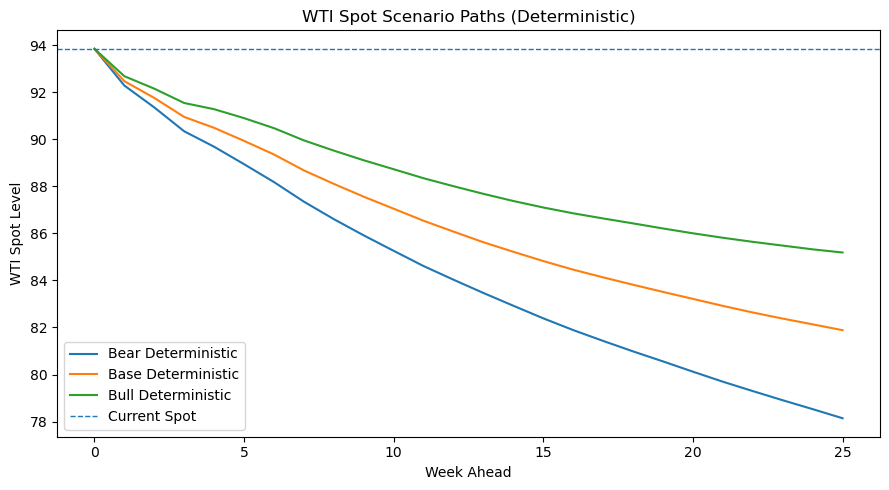

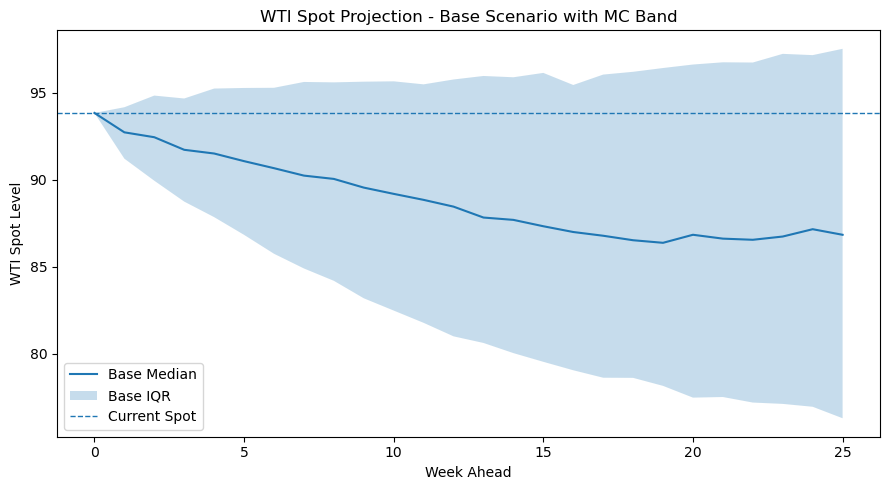

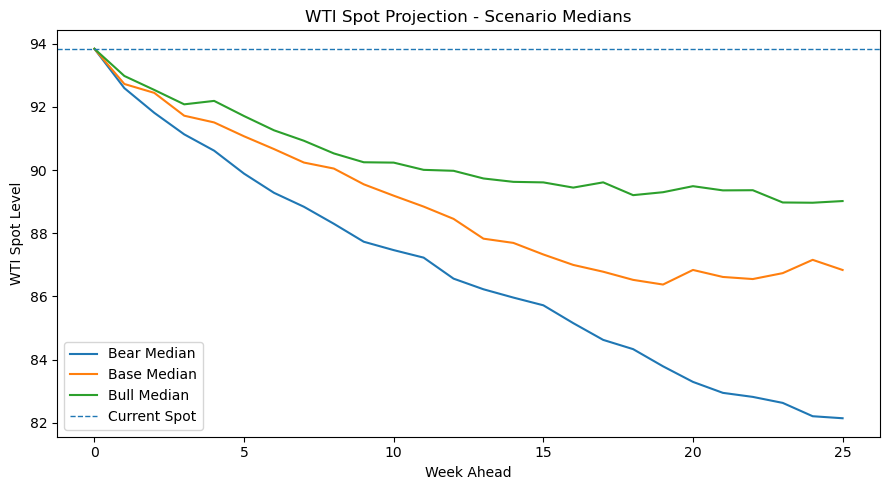


Saved files:
- spot_deterministic_scenario_paths.csv
- spot_scenario_mc_summary.csv


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 0) OBJECTS ALREADY IN YOUR NOTEBOOK
# =========================================================
res = mean_results
df_spot = df_ens.copy()

spot_level_col = 'WTI_Spot'
spot_change_col = 'Chng_WTI_Spot'

feature_cols = [
    'Spot-Cl1_lag1',
    'BZ1_CL1_change_lag4',
    'Chng_CushingStocks_lag1'
]

# =========================================================
# 1) CURRENT OBSERVED LEVELS
# =========================================================
latest_row = df_spot.dropna(subset=[spot_level_col, spot_change_col] + feature_cols).iloc[-1]

current_spot_level = latest_row[spot_level_col]
last_spot_change = latest_row[spot_change_col]

print("Current spot level:", current_spot_level)
print("Last observed weekly spot change:", last_spot_change)

# =========================================================
# 2) EXTRACT SARIMAX COEFFICIENTS
# =========================================================
params = res.params.copy()

print("\nSARIMAX params:")
print(params)

const = params.get('intercept', params.get('const', 0.0))
ar1 = params.get('ar.L1', 0.0)

beta_map = {}
for feat in feature_cols:
    if feat in params.index:
        beta_map[feat] = params[feat]
    else:
        raise ValueError(f"Could not find coefficient for feature: {feat}")

print("\nExtracted coefficients:")
print("const:", const)
print("ar1:", ar1)
print("betas:", beta_map)

# =========================================================
# 3) RESHAPE assumption_table_t0 INTO FEATURE PATH TABLES
# ---------------------------------------------------------
# Each becomes:
# index = week
# columns = feature names
# values = feature levels for that scenario path
# =========================================================
def build_feature_path_table(assumption_df, path_col):
    temp = assumption_df.pivot(
        index='week',
        columns='feature',
        values=path_col
    ).copy()

    temp = temp[feature_cols]
    temp = temp.sort_index()
    return temp

bear_feature_path = build_feature_path_table(assumption_table_t0, 'bear_path')
base_feature_path = build_feature_path_table(assumption_table_t0, 'base_path')
bull_feature_path = build_feature_path_table(assumption_table_t0, 'bull_path')

print("\nBase feature path:")
print(base_feature_path.head())

# =========================================================
# 4) DETERMINISTIC SPOT PATHS
# ---------------------------------------------------------
# This uses the scenario feature paths directly.
# Week 0 is the current anchor.
# =========================================================
def project_spot_path_from_features(
    feature_path_df,
    feature_cols,
    const,
    ar1,
    beta_map,
    current_spot_level,
    last_spot_change
):
    weeks = feature_path_df.index.tolist()

    spot_changes = []
    spot_levels = []

    prev_change = last_spot_change
    prev_level = current_spot_level

    for week in weeks:
        if week == 0:
            spot_changes.append(prev_change)
            spot_levels.append(prev_level)
            continue

        exog_vals = feature_path_df.loc[week, feature_cols]

        pred_change = const + ar1 * prev_change
        for feat in feature_cols:
            pred_change += beta_map[feat] * exog_vals[feat]

        next_level = prev_level + pred_change

        spot_changes.append(pred_change)
        spot_levels.append(next_level)

        prev_change = pred_change
        prev_level = next_level

    out = pd.DataFrame({
        'week': weeks,
        'spot_change': spot_changes,
        'spot_level': spot_levels
    })

    return out

bear_spot_det = project_spot_path_from_features(
    bear_feature_path, feature_cols, const, ar1, beta_map,
    current_spot_level, last_spot_change
)

base_spot_det = project_spot_path_from_features(
    base_feature_path, feature_cols, const, ar1, beta_map,
    current_spot_level, last_spot_change
)

bull_spot_det = project_spot_path_from_features(
    bull_feature_path, feature_cols, const, ar1, beta_map,
    current_spot_level, last_spot_change
)

print("\nDeterministic Base Spot Path:")
print(base_spot_det)

# run Monte Carlo and set parameters
def monte_carlo_spot_from_feature_path(
    feature_path_df,
    feature_cols,
    const,
    ar1,
    beta_map,
    current_spot_level,
    last_spot_change,
    resid,
    n_sims=2000,
    seed=42
):
    rng = np.random.default_rng(seed)

    resid_pool = pd.Series(resid).dropna().values
    weeks = feature_path_df.index.tolist()
    horizon = len(weeks)

    spot_change_paths = np.zeros((n_sims, horizon))
    spot_level_paths = np.zeros((n_sims, horizon))

    for sim in range(n_sims):
        prev_change = last_spot_change
        prev_level = current_spot_level

        for i, week in enumerate(weeks):
            if week == 0:
                spot_change_paths[sim, i] = prev_change
                spot_level_paths[sim, i] = prev_level
                continue

            exog_vals = feature_path_df.loc[week, feature_cols]

            pred_change = const + ar1 * prev_change
            for feat in feature_cols:
                pred_change += beta_map[feat] * exog_vals[feat]

            shock = resid_pool[rng.integers(low=0, high=len(resid_pool))]
            pred_change += shock

            next_level = prev_level + pred_change

            spot_change_paths[sim, i] = pred_change
            spot_level_paths[sim, i] = next_level

            prev_change = pred_change
            prev_level = next_level

    return weeks, spot_change_paths, spot_level_paths

n_sims = 2000

bear_weeks, bear_change_mc, bear_level_mc = monte_carlo_spot_from_feature_path(
    bear_feature_path, feature_cols, const, ar1, beta_map,
    current_spot_level, last_spot_change, resid, n_sims=n_sims, seed=42
)

base_weeks, base_change_mc, base_level_mc = monte_carlo_spot_from_feature_path(
    base_feature_path, feature_cols, const, ar1, beta_map,
    current_spot_level, last_spot_change, resid, n_sims=n_sims, seed=43
)

bull_weeks, bull_change_mc, bull_level_mc = monte_carlo_spot_from_feature_path(
    bull_feature_path, feature_cols, const, ar1, beta_map,
    current_spot_level, last_spot_change, resid, n_sims=n_sims, seed=44
)

# =========================================================
# 6) SUMMARIZE MONTE CARLO OUTPUT
# =========================================================
def summarize_mc_paths(weeks, level_paths, change_paths, scenario_name):
    rows = []

    for i, week in enumerate(weeks):
        lvl_vals = level_paths[:, i]
        chg_vals = change_paths[:, i]

        rows.append({
            'scenario': scenario_name,
            'week': week,
            'spot_p10': np.quantile(lvl_vals, 0.10),
            'spot_p25': np.quantile(lvl_vals, 0.25),
            'spot_median': np.quantile(lvl_vals, 0.50),
            'spot_p75': np.quantile(lvl_vals, 0.75),
            'spot_p90': np.quantile(lvl_vals, 0.90),
            'spot_mean': np.mean(lvl_vals),
            'spot_std': np.std(lvl_vals),

            'chg_p10': np.quantile(chg_vals, 0.10),
            'chg_p25': np.quantile(chg_vals, 0.25),
            'chg_median': np.quantile(chg_vals, 0.50),
            'chg_p75': np.quantile(chg_vals, 0.75),
            'chg_p90': np.quantile(chg_vals, 0.90),
        })

    return pd.DataFrame(rows).round(3)

bear_summary = summarize_mc_paths(bear_weeks, bear_level_mc, bear_change_mc, 'Bear')
base_summary = summarize_mc_paths(base_weeks, base_level_mc, base_change_mc, 'Base')
bull_summary = summarize_mc_paths(bull_weeks, bull_level_mc, bull_change_mc, 'Bull')

spot_summary_all = pd.concat([bear_summary, base_summary, bull_summary], axis=0, ignore_index=True)

print("\nSpot summary:")
print(spot_summary_all.head(15))


deterministic_paths = (
    bear_spot_det[['week', 'spot_level', 'spot_change']].rename(columns={
        'spot_level': 'bear_det_spot',
        'spot_change': 'bear_det_change'
    })
    .merge(
        base_spot_det[['week', 'spot_level', 'spot_change']].rename(columns={
            'spot_level': 'base_det_spot',
            'spot_change': 'base_det_change'
        }),
        on='week'
    )
    .merge(
        bull_spot_det[['week', 'spot_level', 'spot_change']].rename(columns={
            'spot_level': 'bull_det_spot',
            'spot_change': 'bull_det_change'
        }),
        on='week'
    )
)

print("\nDeterministic spot paths:")
print(deterministic_paths)



# A) deterministic Bear / Base / Bull paths
plt.figure(figsize=(9, 5))
plt.plot(deterministic_paths['week'], deterministic_paths['bear_det_spot'], label='Bear Deterministic')
plt.plot(deterministic_paths['week'], deterministic_paths['base_det_spot'], label='Base Deterministic')
plt.plot(deterministic_paths['week'], deterministic_paths['bull_det_spot'], label='Bull Deterministic')
plt.axhline(current_spot_level, linewidth=1, linestyle='--', label='Current Spot')
plt.title('WTI Spot Scenario Paths (Deterministic)')
plt.xlabel('Week Ahead')
plt.ylabel('WTI Spot Level')
plt.legend()
plt.tight_layout()
plt.show()

# B) base scenario with MC band
plt.figure(figsize=(9, 5))
plt.plot(base_summary['week'], base_summary['spot_median'], label='Base Median')
plt.fill_between(
    base_summary['week'],
    base_summary['spot_p25'],
    base_summary['spot_p75'],
    alpha=0.25,
    label='Base IQR'
)
plt.axhline(current_spot_level, linewidth=1, linestyle='--', label='Current Spot')
plt.title('WTI Spot Projection - Base Scenario with MC Band')
plt.xlabel('Week Ahead')
plt.ylabel('WTI Spot Level')
plt.legend()
plt.tight_layout()
plt.show()

# C) scenario medians
plt.figure(figsize=(9, 5))
plt.plot(bear_summary['week'], bear_summary['spot_median'], label='Bear Median')
plt.plot(base_summary['week'], base_summary['spot_median'], label='Base Median')
plt.plot(bull_summary['week'], bull_summary['spot_median'], label='Bull Median')
plt.axhline(current_spot_level, linewidth=1, linestyle='--', label='Current Spot')
plt.title('WTI Spot Projection - Scenario Medians')
plt.xlabel('Week Ahead')
plt.ylabel('WTI Spot Level')
plt.legend()
plt.tight_layout()
plt.show()

#Save Outputs
deterministic_paths.to_csv('spot_deterministic_scenario_paths.csv', index=False)
spot_summary_all.to_csv('spot_scenario_mc_summary.csv', index=False)

print("\nSaved files:")
print("- spot_deterministic_scenario_paths.csv")
print("- spot_scenario_mc_summary.csv")